### Baixar dataset

In [201]:
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster import hierarchy
import numpy as np

In [202]:
api = KaggleApi()
api.authenticate()
file = api.dataset_download_files("rohan0301/unsupervised-learning-on-country-data", path='./', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data


In [203]:
original_df = pd.read_csv("Country-data.csv")
df_dd = pd.read_csv("data-dictionary.csv")
original_df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Exploração Dados

In [204]:
original_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [205]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


#### 2. Quantos países existem no dataset?
R: 167 países

In [206]:
df = original_df.drop(columns=['country'])

### 3. Visualização dos dados / pré-processamento
R: Os gráficos abaixo mostram como os dados estão dispersos e como algumas features possuem outliers. É necessário fazer uma padronização para deixar todos na mesma faixa.

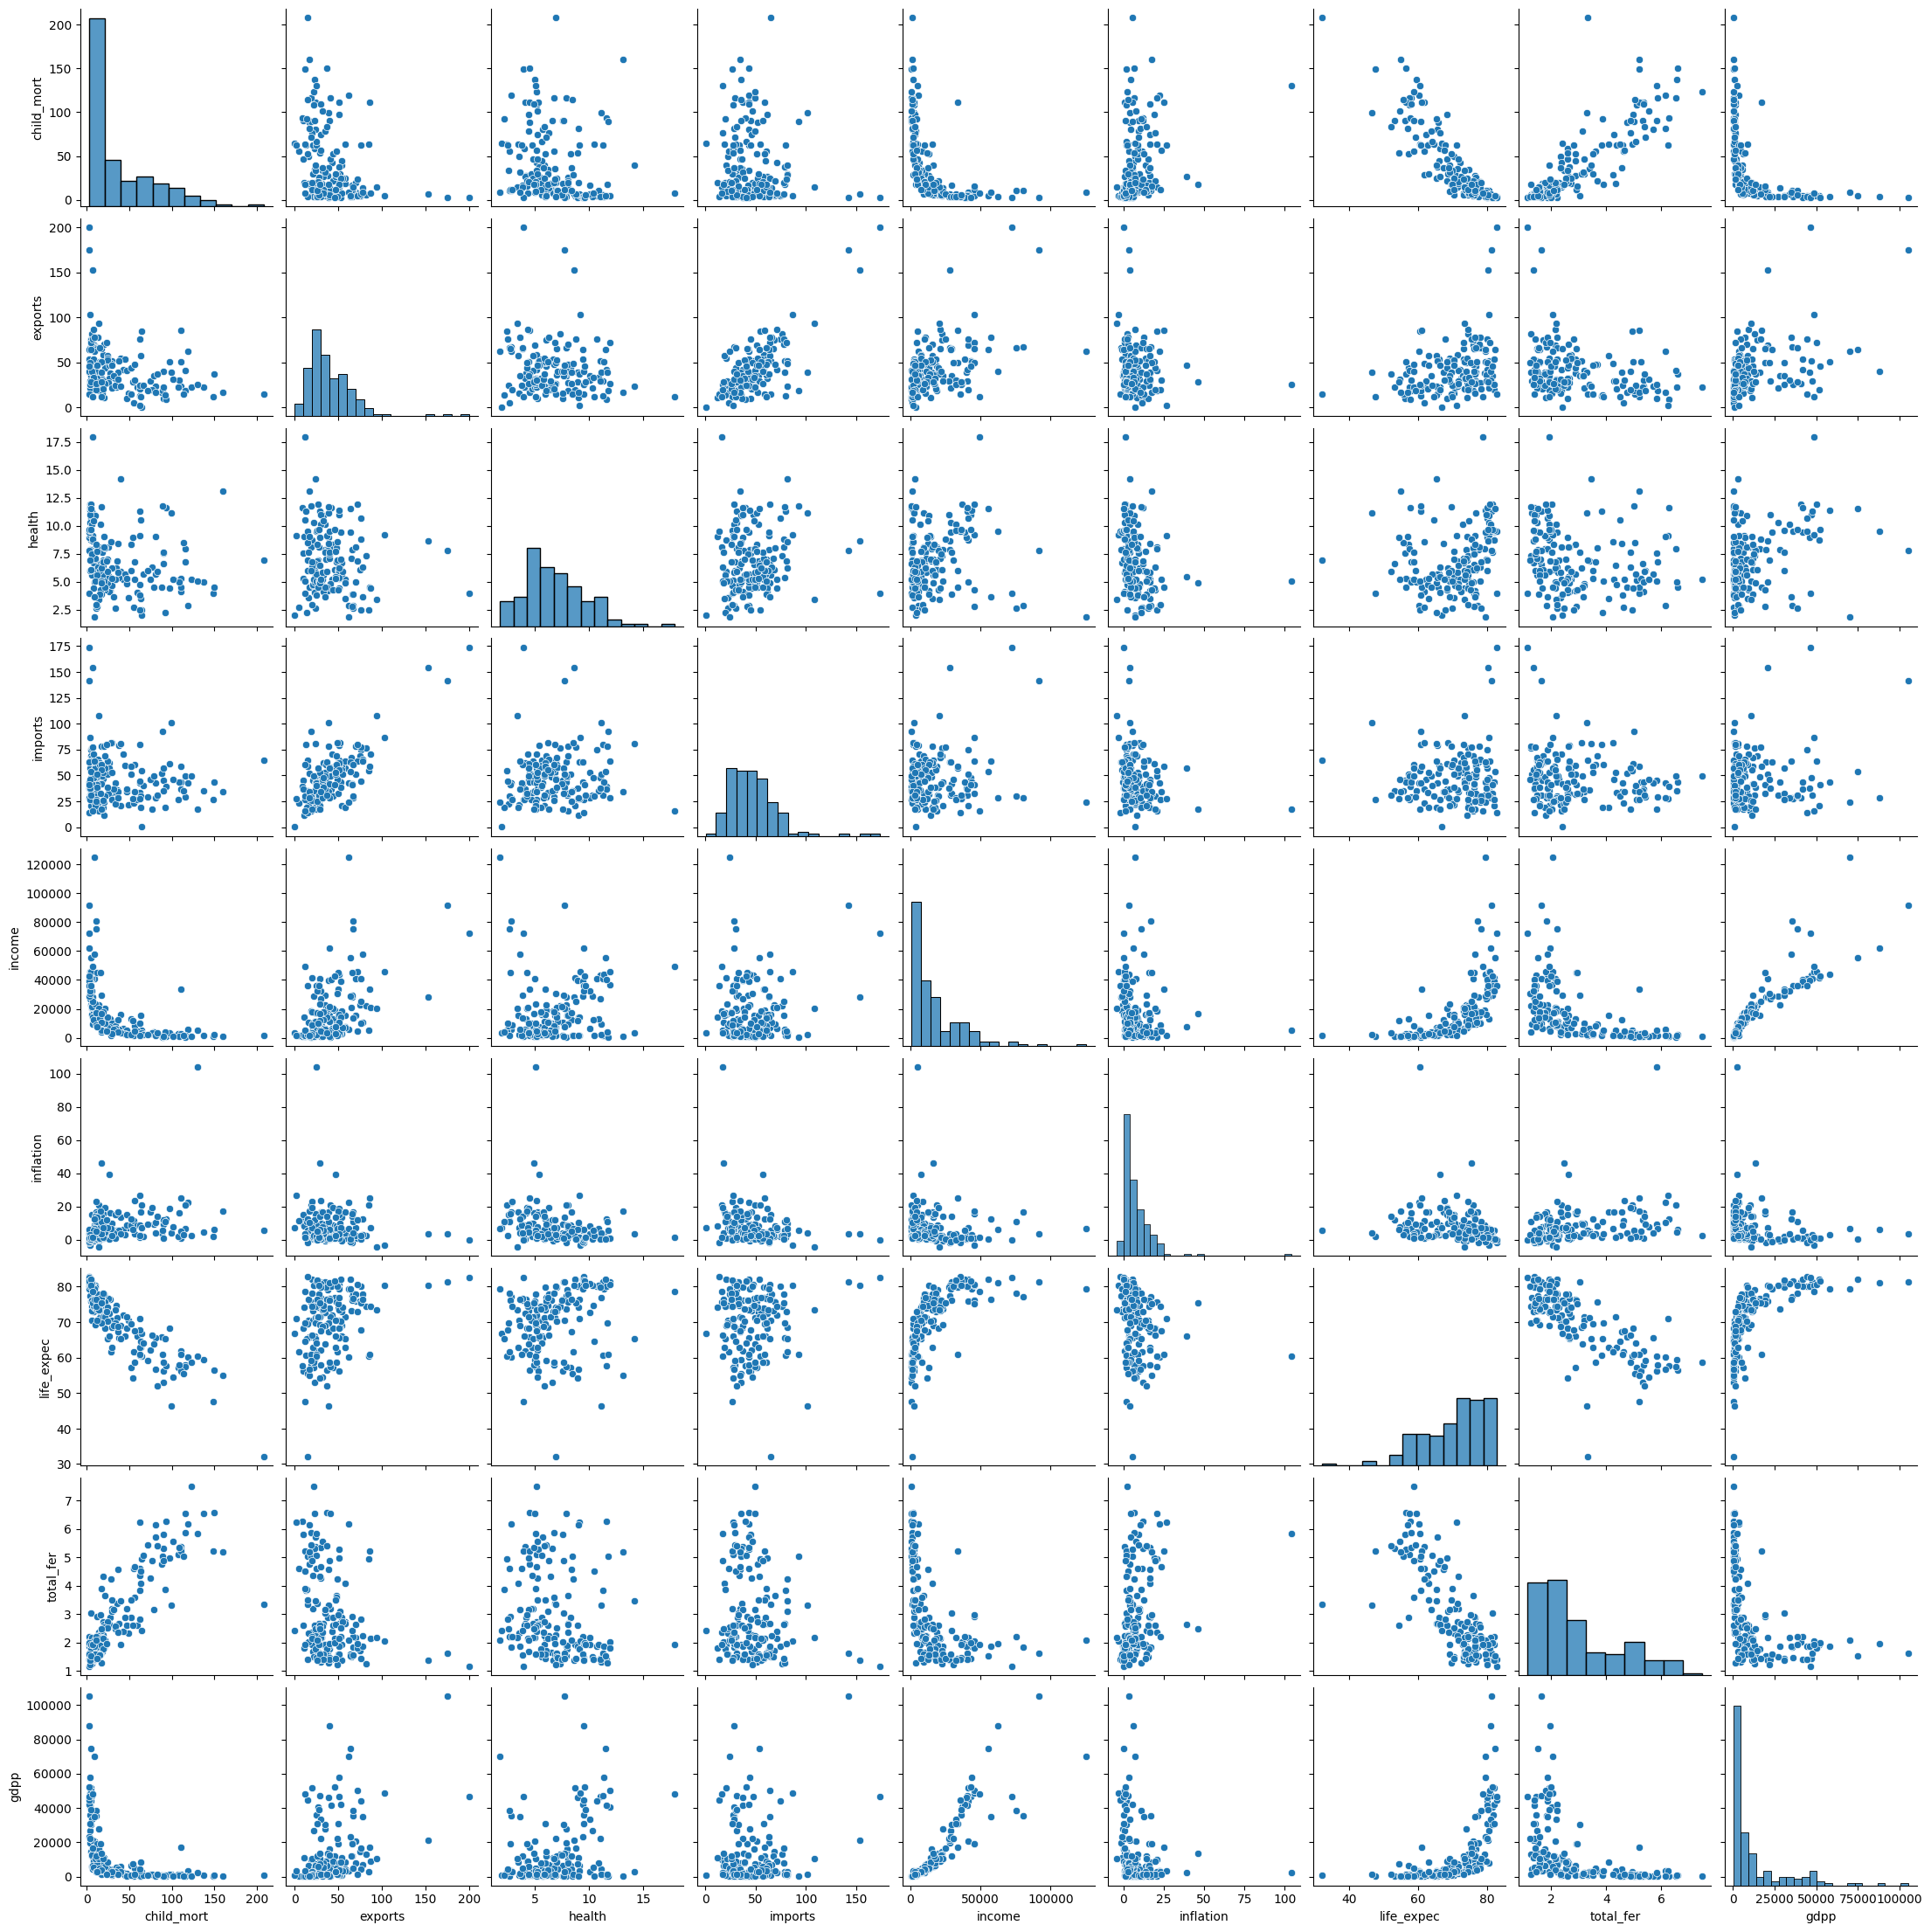

In [207]:
sns.pairplot(df)

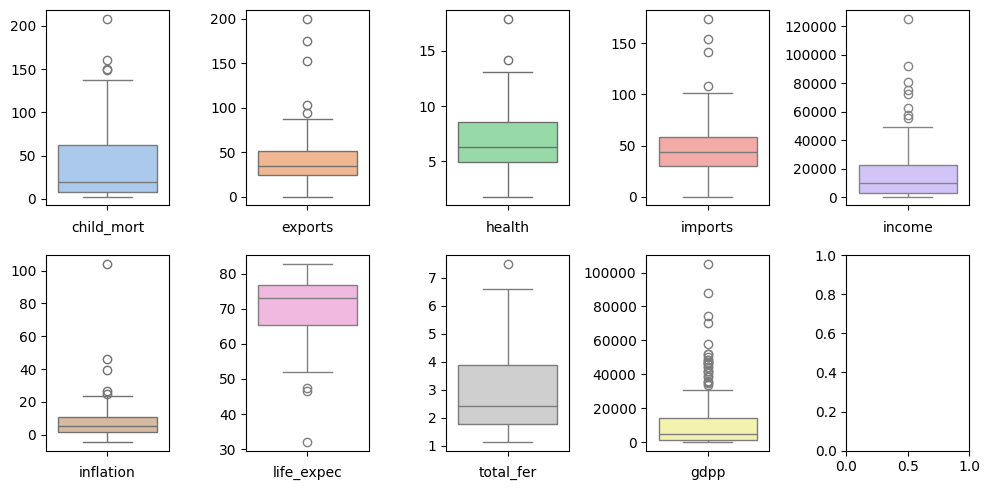

In [208]:
fig, ax = plt.subplots(2, 5, figsize=(10, 5))
colors = sns.color_palette('pastel')

for i, column in enumerate(df.columns):
    sns.boxplot(data=df[column], ax=ax.flatten()[i], color=colors[i])
    ax.flatten()[i].set_ylabel("") 
    ax.flatten()[i].set_xlabel(column) 

plt.tight_layout()
plt.show()

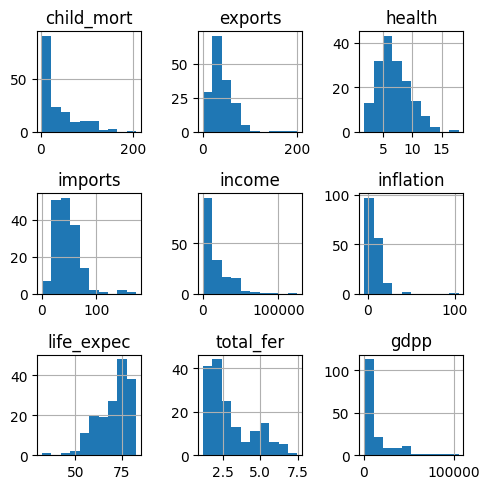

In [209]:
df.hist(figsize=(5,5))
plt.tight_layout()

In [210]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

In [211]:
scaled_df = pd.DataFrame(X, columns=['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp'])
scaled_df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
...,...,...,...,...,...,...,...,...,...
162,-0.225578,0.200917,-0.571711,0.240700,-0.738527,-0.489784,-0.852161,0.365754,-0.546913
163,-0.526514,-0.461363,-0.695862,-1.213499,-0.033542,3.616865,0.546361,-0.316678,0.029323
164,-0.372315,1.130305,0.008877,1.380030,-0.658404,0.409732,0.286958,-0.661206,-0.637754
165,0.448417,-0.406478,-0.597272,-0.517472,-0.658924,1.500916,-0.344633,1.140944,-0.637754


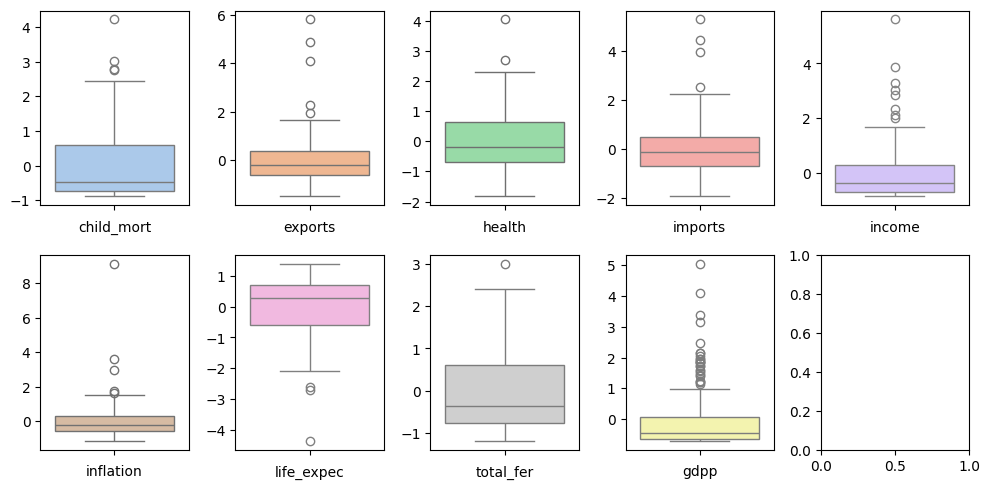

In [212]:
fig, ax = plt.subplots(2, 5, figsize=(10, 5))
colors = sns.color_palette('pastel')
for i, column in enumerate(scaled_df.columns):
    sns.boxplot(data=scaled_df[column], ax=ax.flatten()[i], color=colors[i])
    ax.flatten()[i].set_ylabel("") 
    ax.flatten()[i].set_xlabel(column) 

plt.tight_layout()
plt.show()

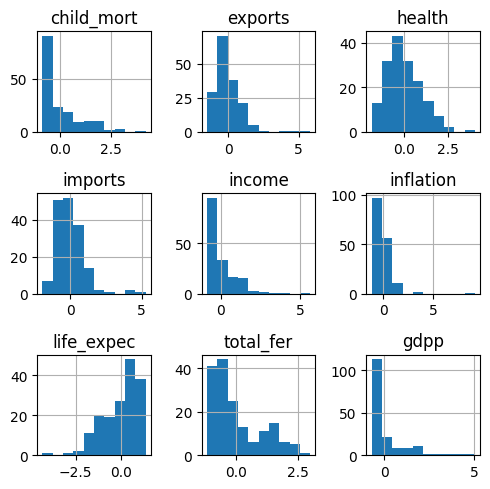

In [213]:
scaled_df.hist(figsize=(5,5))
plt.tight_layout()

### Clusterização k-means e hierárquica

In [214]:
CLUSTERS = 3
SEED = 10

kmeans = KMeans(n_clusters=CLUSTERS, random_state=SEED).fit(X)
df['cluster'] = kmeans.labels_

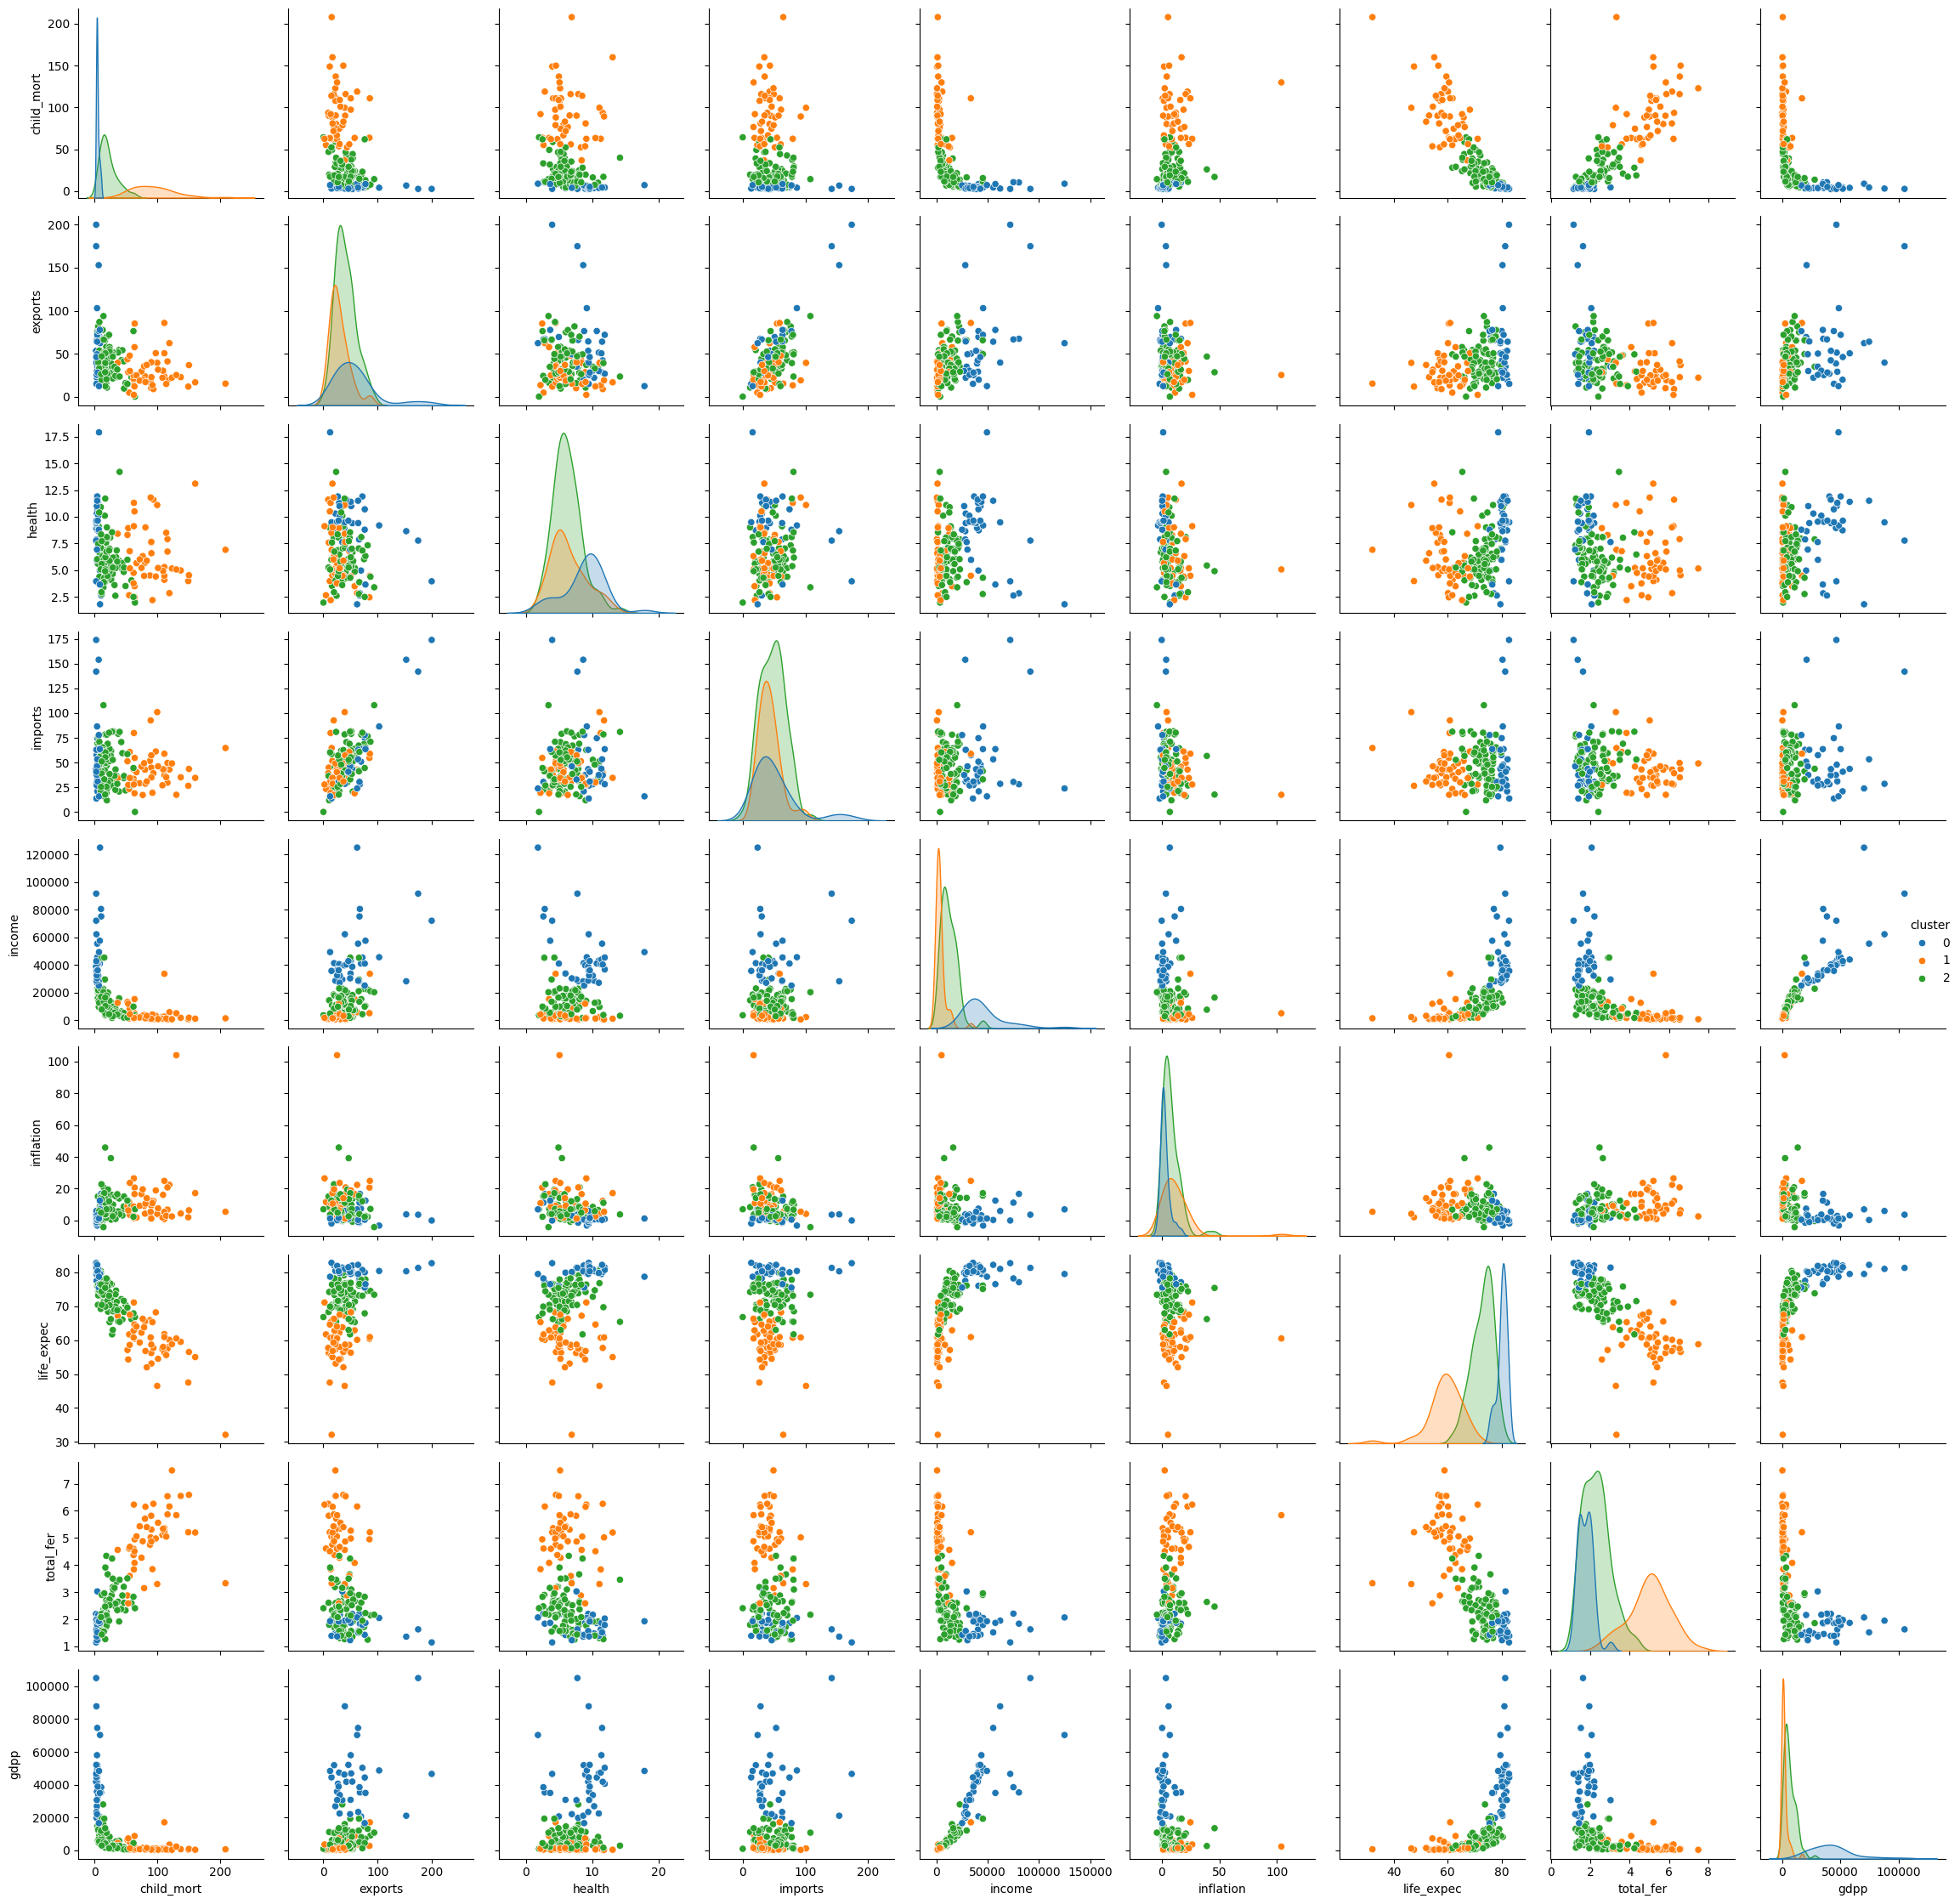

In [215]:
sns.pairplot(df, hue='cluster', palette='tab10')
plt.tight_layout()

In [216]:
df['cluster'].value_counts()

cluster
2    84
1    47
0    36
Name: count, dtype: int64

#### Qual a distribuição das dimensões em cada grupo:

A distribuição de cada grupo resultante do KMeans tem a seguinte distribuição:
- Cluster 0: 36 países
- Cluster 1: 47 países
- Cluster 2: 84 países

In [217]:
paises = []
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.drop(columns=['cluster']).columns)

for cluster in range(CLUSTERS): 
    pontos = X[df['cluster'] == cluster]
    paises_cluster = original_df.loc[df['cluster'] == cluster, 'country']

    distancias = []
    for ponto in pontos:
        dist = np.sqrt(np.sum((ponto - kmeans.cluster_centers_[cluster]) ** 2))
        distancias.append(dist)

    min_dist = np.argmin(distancias)
    pais = paises_cluster.iloc[min_dist]

    paises.append((cluster, pais))

for cluster, pais in paises:
    print(cluster, pais)

0 Iceland
1 Guinea
2 Jamaica


#### O país, de acordo com o algoritmo, melhor representa o seu agrupamento.
R: O país que melhor representa cada cluster é o país mais perto do centroide. Os países mais próximos de seus centroides são: Islândia, Guiné e Jamaica.

#### Clusterização Hierarquica

In [218]:
single_linkage = hierarchy.linkage(X, method='single', metric='euclidean')
complete_linkage = hierarchy.linkage(X, method='complete', metric='euclidean')

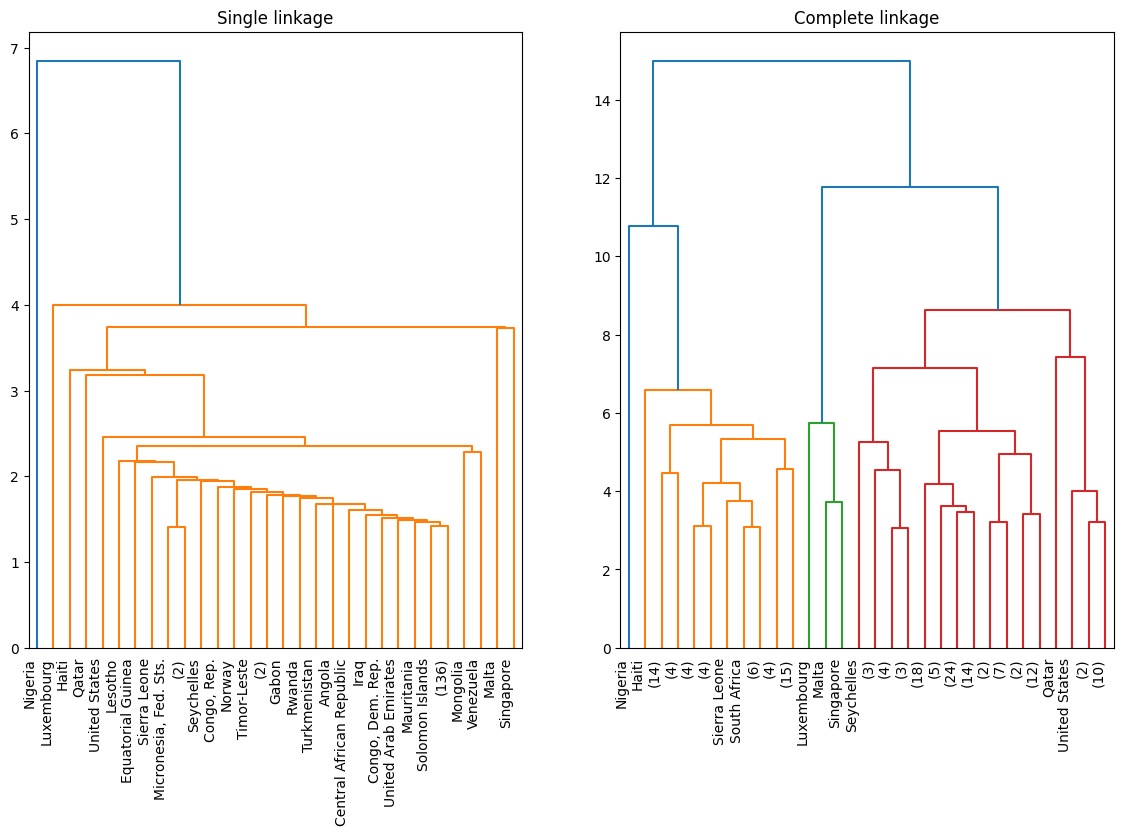

In [219]:
fig, ax = plt.subplots(1, 2, figsize=(14, 8))
hierarchy.dendrogram(single_linkage, distance_sort=True, show_leaf_counts=True, truncate_mode='lastp', ax=ax[0], labels=original_df['country'].values)
hierarchy.dendrogram(complete_linkage, distance_sort=True, show_leaf_counts=True, truncate_mode='lastp', ax=ax[1], labels=original_df['country'].values)
ax[0].set_title('Single linkage')
ax[1].set_title('Complete linkage')
plt.setp(ax[0].get_xticklabels(), rotation=90, ha='right')
plt.setp(ax[1].get_xticklabels(), rotation=90, ha='right')
plt.show()

In [220]:
agg = AgglomerativeClustering(n_clusters=CLUSTERS, linkage='ward').fit(X)
df['agg'] = agg.labels_

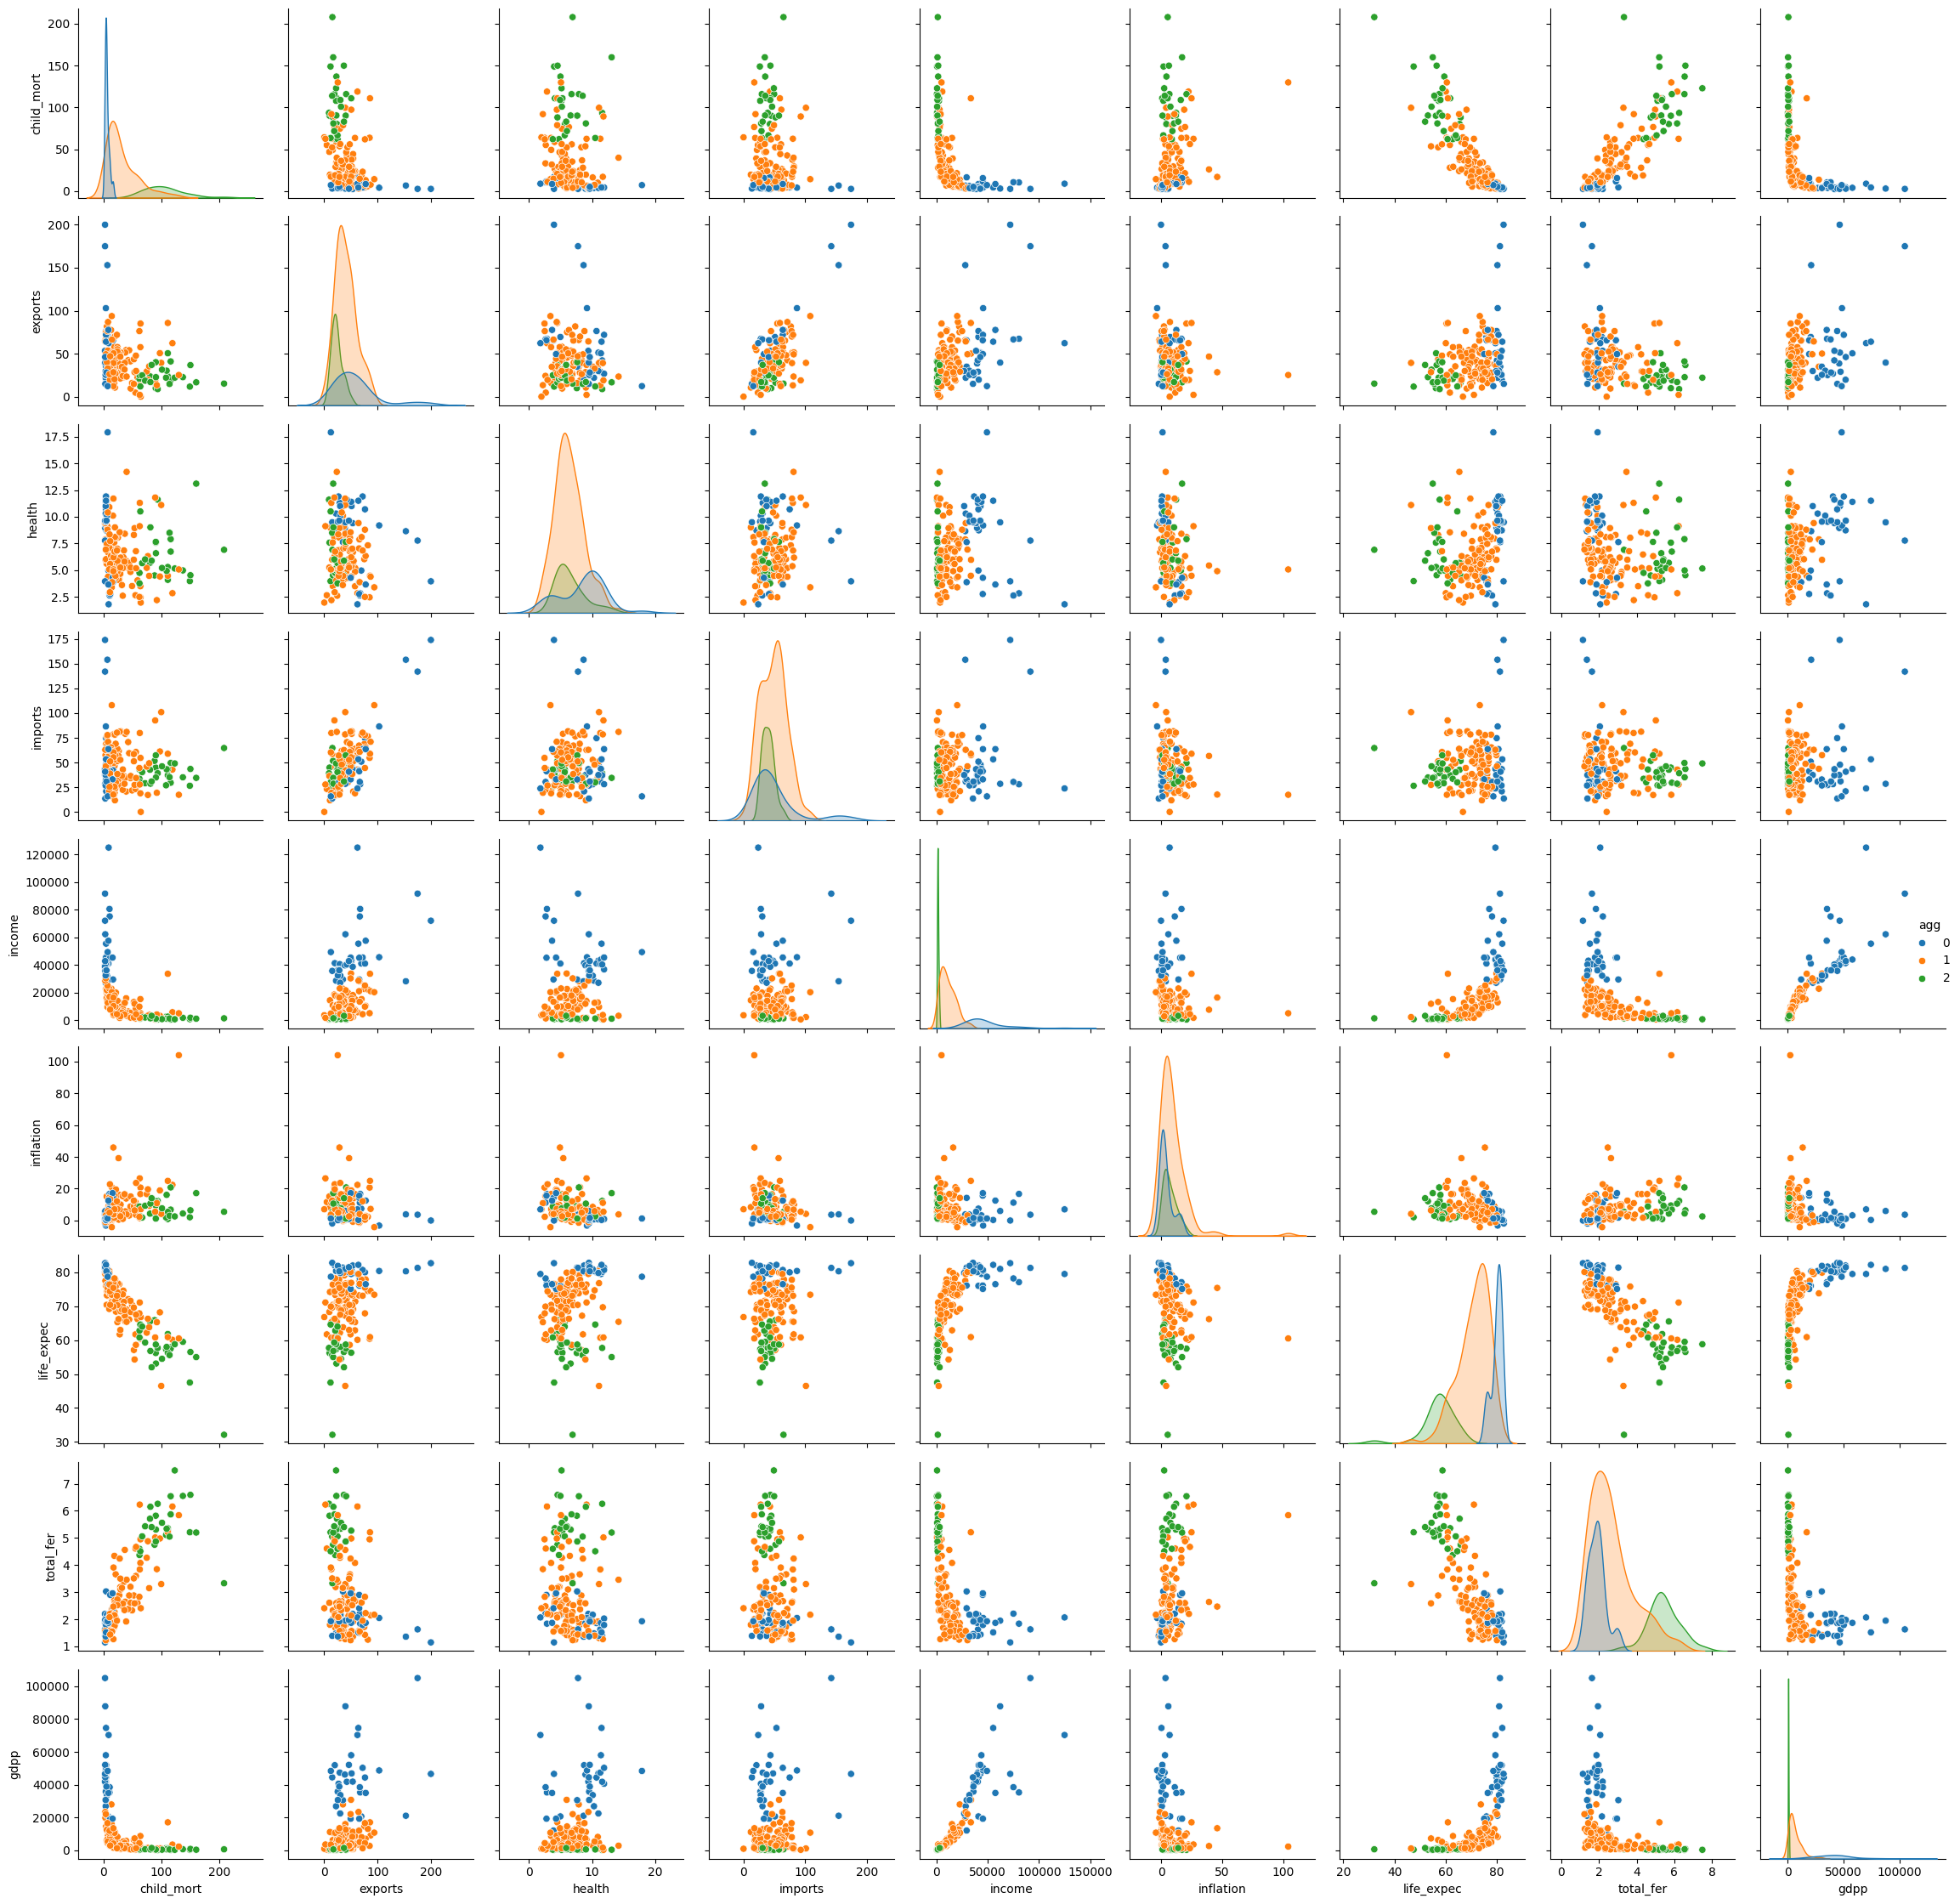

In [221]:
sns.pairplot(data=df.drop(columns=['cluster']), hue='agg', palette='tab10')
plt.tight_layout()

### Compare os dois resultados, aponte as semelhanças e diferenças e interprete.
R: Análisando os gráficos e as médias geradas por cada método de clusterização é possível notar que os resultados são bem semelhantes. É possível notar como o KMeans e Clusterização Hierárquica possuem dificuldade em agrupar dados que são densos, o gráfico mostra como o mesmo país pode acabar em grupos diferentes dependendo do algoritmo utilizado. 

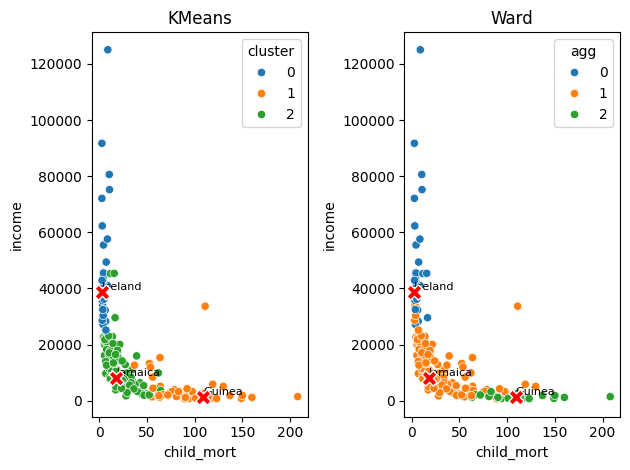

In [222]:
f, ax = plt.subplots(1, 2)

sns.scatterplot(data=df, x=df.iloc[:, 0], y=df.iloc[:, 4], hue='cluster', ax=ax[0], palette='tab10')
sns.scatterplot(data=df, x=df.iloc[:, 0], y=df.iloc[:, 4], hue='agg', ax=ax[1], palette='tab10')

ax[0].set_title("KMeans")
ax[1].set_title("Ward")

for cluster_id, pais in paises:
    row = original_df[original_df['country'] == pais]
    x_val = row.iloc[0, 1]
    y_val = row.iloc[0, 5]

    ax[0].scatter(x_val, y_val, color='red', s=120, marker='X', edgecolor='white', zorder=5)
    ax[0].text(x_val, y_val, pais, fontsize=8, color='black', ha='left', va='bottom')

    ax[1].scatter(x_val, y_val, color='red', s=120, marker='X', edgecolor='white', zorder=5)
    ax[1].text(x_val, y_val, pais, fontsize=8, color='black', ha='left', va='bottom')

plt.tight_layout()

In [223]:
df.drop(columns=['agg']).groupby('cluster').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [224]:
df.drop(columns=['cluster']).groupby('agg').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
agg,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889
